# UCEC Tumor Grade Classification from Transcriptomic Data

**Author:** Zahin Peerzade  
**Dataset:** TCGA UCEC (Uterine Corpus Endometrial Carcinoma)  
**Task:** Binary classification — predict tumor grade (Grade II− vs Grade III+) from RNA-seq gene expression features  
**Primary Metric:** F1-Score (competition target)

---

## Overview

This notebook builds a supervised ML pipeline to classify endometrial tumor grade using high-dimensional transcriptomic data (~18,000 gene-level features). The approach covers:

1. **Data loading & integrity checks** — shape verification, label distribution, ID alignment  
2. **Baseline model comparison** — Linear, Logistic, Ridge, and LASSO regression under stratified 5-fold CV  
3. **Regularization hyperparameter sweep** — alpha grid search for Ridge and LASSO  
4. **Univariate feature selection** — SelectKBest (ANOVA F-statistic) sweep over k values  
5. **Sanity check via y-randomization** — verifying that learned signal is real, not an artifact  
6. **Gene importance analysis** — ranking genes by logistic regression coefficients  
7. **Dimensionality reduction & visualization** — PCA and t-SNE of the training samples  
8. **Final prediction & submission** — retrain on all 444 samples, generate test predictions

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.utils import shuffle

## 2. Data Loading & Integrity Checks

The dataset contains:
- **444 training samples** × ~18,000 gene-level features
- **110 held-out test samples** (no labels)
- Labels are binary: `0` = Grade II−, `1` = Grade III+

Key checks performed:
- Shape verification across all three files
- Drop the index column if present (unnamed first column)
- Confirm no missing values
- Inspect class balance — important for interpreting F1

In [2]:
# Load data — update paths if running locally vs. in the original competition environment
train_X = pd.read_csv('../data/train_X.csv')
train_y = pd.read_csv('../data/train_y.csv')
test_X  = pd.read_csv('../data/test_X.csv')

print("Train X shape:", train_X.shape)
print("Train y shape:", train_y.shape)
print("Test X shape: ", test_X.shape)
print("\nFirst few rows of train_y:")
print(train_y.head())

Train X shape: (444, 17971)
Train y shape: (444, 2)
Test X shape:  (110, 17971)

First few rows of train_y:
                             Unnamed: 0  xml_neoplasm_histologic_grade
0  EB0D68BC-5FF9-44A5-A355-CA5441BFBA0A                              0
1  0876B4BB-58BA-4C4C-84F4-E9D19EF96147                              1
2  EACD1021-7B52-4531-8806-B7555B73AC84                              0
3  368ACD26-C7FB-4974-BB7F-0AE22670CB0E                              0
4  F23B0A1A-25AE-41D9-8C49-B692C4FDE1E4                              1


In [3]:
# Extract labels
y_train = train_y['xml_neoplasm_histologic_grade'].values

# Drop the unnamed index column if present (common in TCGA exports)
if 'Unnamed: 0' in train_X.columns or 'Unnamed' in str(train_X.columns[0]):
    X_train = train_X.iloc[:, 1:].values
    X_test  = test_X.iloc[:, 1:].values
    gene_names = train_X.columns[1:].tolist()
else:
    X_train = train_X.values
    X_test  = test_X.values
    gene_names = train_X.columns.tolist()

# Capture test IDs for submission
test_ids = test_X.iloc[:, 0].values

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print(f"\nMissing values — train_X: {train_X.isnull().sum().sum()}, test_X: {test_X.isnull().sum().sum()}")
print(f"\nClass distribution:")
print(f"  Grade II-  (0): {np.sum(y_train == 0)} samples ({np.mean(y_train == 0)*100:.1f}%)")
print(f"  Grade III+ (1): {np.sum(y_train == 1)} samples ({np.mean(y_train == 1)*100:.1f}%)")

X_train shape: (444, 17970)
X_test shape:  (110, 17970)
y_train shape: (444,)

Missing values — train_X: 0, test_X: 0

Class distribution:
  Grade II-  (0): 190 samples (42.8%)
  Grade III+ (1): 254 samples (57.2%)


## 3. Baseline Model Comparison

We compare four models under the same evaluation protocol:
- **Stratified 5-fold CV** — preserves class proportions across folds
- **Pipeline with StandardScaler** — scaler fit only on training folds to prevent data leakage
- Regression models (Linear, Ridge, LASSO) use a 0.5 threshold on their continuous output to produce binary predictions

Primary metric is **F1-score**; accuracy is reported as a reference.

In [4]:
# Define models
models = {
    "Linear Regression":  LinearRegression(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Ridge Regression":   Ridge(alpha=1.0, random_state=42),
    "Lasso Regression":   Lasso(alpha=0.01, random_state=42, max_iter=5000)
}

# Regression models require thresholding their continuous output
REGRESSION_MODELS = {"Linear Regression", "Ridge Regression", "Lasso Regression"}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for model_name, model in models.items():
    # Wrap in Pipeline so StandardScaler is fit only on training folds
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    y_pred = cross_val_predict(pipe, X_train, y_train, cv=cv)

    if model_name in REGRESSION_MODELS:
        y_pred = (y_pred >= 0.5).astype(int)

    acc = accuracy_score(y_train, y_pred)
    f1  = f1_score(y_train, y_pred)

    results.append({'Model': model_name, 'Accuracy': acc, 'F1-Score': f1})
    print(f"{model_name:<25} Accuracy: {acc:.4f}  F1: {f1:.4f}")

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print("\n--- Summary (sorted by F1) ---")
print(results_df.to_string(index=False))

Linear Regression         Accuracy: 0.8131  F1: 0.8363
Logistic Regression       Accuracy: 0.8221  F1: 0.8460
Ridge Regression          Accuracy: 0.8131  F1: 0.8363
Lasso Regression          Accuracy: 0.8041  F1: 0.8277

--- Summary (sorted by F1) ---
              Model  Accuracy  F1-Score
Logistic Regression  0.822072  0.846004
  Linear Regression  0.813063  0.836292
   Ridge Regression  0.813063  0.836292
   Lasso Regression  0.804054  0.827723


## 4. Regularization Hyperparameter Sweep (Ridge & LASSO)

Ridge (L2) and LASSO (L1) both have a penalty strength hyperparameter `alpha`. A sweep over 7 log-spaced values identifies the best alpha for each, still under the same 5-fold CV protocol.

In [5]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_results, lasso_results = [], []

print("Ridge Regression alpha sweep:")
for alpha in alphas:
    pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=alpha, random_state=42))])
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=cv)
    y_pred = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y_train, y_pred)
    f1  = f1_score(y_train, y_pred)
    ridge_results.append({'Alpha': alpha, 'Accuracy': acc, 'F1-Score': f1})
    print(f"  alpha={alpha:8.3f}  Accuracy={acc:.4f}  F1={f1:.4f}")

print("\nLasso Regression alpha sweep:")
for alpha in alphas:
    pipe = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=alpha, random_state=42, max_iter=5000))])
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=cv)
    y_pred = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y_train, y_pred)
    f1  = f1_score(y_train, y_pred)
    lasso_results.append({'Alpha': alpha, 'Accuracy': acc, 'F1-Score': f1})
    print(f"  alpha={alpha:8.3f}  Accuracy={acc:.4f}  F1={f1:.4f}")

ridge_df = pd.DataFrame(ridge_results)
lasso_df = pd.DataFrame(lasso_results)
best_ridge = ridge_df.loc[ridge_df['F1-Score'].idxmax()]
best_lasso = lasso_df.loc[lasso_df['F1-Score'].idxmax()]

print(f"\nBest Ridge: alpha={best_ridge['Alpha']}, F1={best_ridge['F1-Score']:.4f}")
print(f"Best Lasso: alpha={best_lasso['Alpha']}, F1={best_lasso['F1-Score']:.4f}")

Ridge Regression alpha sweep:
  alpha=   0.001  Accuracy=0.8131  F1=0.8363
  alpha=   0.010  Accuracy=0.8131  F1=0.8363
  alpha=   0.100  Accuracy=0.8131  F1=0.8363
  alpha=   1.000  Accuracy=0.8131  F1=0.8363
  alpha=  10.000  Accuracy=0.8131  F1=0.8363
  alpha= 100.000  Accuracy=0.8131  F1=0.8363
  alpha=1000.000  Accuracy=0.8198  F1=0.8431

Lasso Regression alpha sweep:
  alpha=   0.001  Accuracy=0.7860  F1=0.8126
  alpha=   0.010  Accuracy=0.8041  F1=0.8277
  alpha=   0.100  Accuracy=0.7658  F1=0.7992
  alpha=   1.000  Accuracy=0.5721  F1=0.7278
  alpha=  10.000  Accuracy=0.5721  F1=0.7278
  alpha= 100.000  Accuracy=0.5721  F1=0.7278
  alpha=1000.000  Accuracy=0.5721  F1=0.7278

Best Ridge: alpha=1000.0, F1=0.8431
Best Lasso: alpha=0.01, F1=0.8277


## 5. Univariate Feature Selection (SelectKBest)

With ~18,000 features and only 444 samples, the feature space is severely over-parameterized. We use ANOVA F-statistics (`f_classif`) to rank genes by their marginal discriminative power and sweep across multiple values of `k` (number of top features to keep).

**Important:** `SelectKBest` is applied inside the CV loop so the selector is fit only on training folds — no label information from the validation fold leaks into feature selection.

In [6]:
k_values = [100, 500, 1000, 2000, 5000, 10000]
best_k, best_score = None, 0

print("SelectKBest sweep (Logistic Regression, 5-fold CV):")
for k in k_values:
    pipe = Pipeline([
        ('scaler',   StandardScaler()),
        ('selector', SelectKBest(f_classif, k=k)),
        ('model',    LogisticRegression(max_iter=1000, random_state=42))
    ])
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=cv)
    f1 = f1_score(y_train, y_pred)
    print(f"  k={k:6d}  F1={f1:.4f}")
    if f1 > best_score:
        best_score = f1
        best_k = k

print(f"\nBest k: {best_k}  (CV F1 = {best_score:.4f})")

SelectKBest sweep (Logistic Regression, 5-fold CV):
  k=   100  F1=0.7723
  k=   500  F1=0.7976
  k=  1000  F1=0.7890
  k=  2000  F1=0.8323
  k=  5000  F1=0.8431
  k= 10000  F1=0.8487

Best k: 10000  (CV F1 = 0.8487)


## 6. Y-Randomization

Y-randomization shuffles the training labels and repeats the full training + CV procedure 100 times. If the model is learning genuine signal, shuffled-label performance should be near chance. A large gap between the real model's F1 and the shuffled baseline confirms the model is not exploiting leakage or spurious correlations.

In [ ]:
# Real model performance
best_model_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])
y_pred_best = cross_val_predict(best_model_pipe, X_train, y_train, cv=cv)
best_acc = accuracy_score(y_train, y_pred_best)
best_f1  = f1_score(y_train, y_pred_best)

print(f"Real model — Accuracy: {best_acc:.4f}  F1: {best_f1:.4f}")

# Y-randomization baseline (100 trials)
rand_accs, rand_f1s = [], []
for i in range(100):
    y_rand  = shuffle(y_train, random_state=i)
    pipe_r  = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))])
    y_pred_r = cross_val_predict(pipe_r, X_train, y_rand, cv=cv)
    rand_accs.append(accuracy_score(y_rand, y_pred_r))
    rand_f1s.append(f1_score(y_rand, y_pred_r))

print(f"\nY-randomization (100 trials):")
print(f"  Accuracy: {np.mean(rand_accs):.4f} ± {np.std(rand_accs):.4f}")
print(f"  F1-Score: {np.mean(rand_f1s):.4f} ± {np.std(rand_f1s):.4f}")
print(f"\nF1 gap (real vs. shuffled): {best_f1 - np.mean(rand_f1s):.4f}")
print(f"Real model is {best_f1 / np.mean(rand_f1s):.2f}x better than random baseline")

## 7. Gene Importance Analysis

Logistic regression assigns a coefficient to each gene. We rank genes by the **absolute value** of their coefficient:
- **Positive coefficient** - higher expression associated with Grade III+ (more aggressive tumor)
- **Negative coefficient** - higher expression associated with Grade II− (lower grade)

The model was trained on all 444 samples (no CV split) for coefficient extraction, since we want the full-data estimates for biological interpretation.

In [9]:
# Fit final logistic regression on all training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

final_lr = LogisticRegression(max_iter=1000, random_state=42)
final_lr.fit(X_train_scaled, y_train)

# Build gene importance DataFrame
gene_importance = pd.DataFrame({
    'Gene':            gene_names,
    'Coefficient':     final_lr.coef_[0],
    'Abs_Coefficient': np.abs(final_lr.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

print("Top 20 Most Important Genes (by |coefficient|):")
print(gene_importance.head(20).to_string(index=False))

print("\nTop 5 genes pushing toward Grade III+ (positive):")
print(gene_importance.nlargest(5, 'Coefficient')[['Gene','Coefficient']].to_string(index=False))

print("\nTop 5 genes pushing toward Grade II- (negative):")
print(gene_importance.nsmallest(5, 'Coefficient')[['Gene','Coefficient']].to_string(index=False))

# Save results
gene_importance.to_csv('../results/gene_importance.csv', index=False)
print("\nSaved to ../results/gene_importance.csv")

Top 20 Most Important Genes (by |coefficient|):
           Gene  Coefficient  Abs_Coefficient
ENSG00000198812    -0.061720         0.061720
ENSG00000180316     0.058396         0.058396
ENSG00000177947     0.057833         0.057833
ENSG00000221813    -0.057734         0.057734
ENSG00000204928    -0.056433         0.056433
ENSG00000168148    -0.052339         0.052339
ENSG00000150722    -0.051546         0.051546
ENSG00000144290     0.051065         0.051065
ENSG00000196341    -0.050477         0.050477
ENSG00000183269    -0.048545         0.048545
ENSG00000204193     0.048397         0.048397
ENSG00000130595     0.047741         0.047741
ENSG00000137204     0.046252         0.046252
ENSG00000176904    -0.045970         0.045970
ENSG00000125851    -0.045945         0.045945
ENSG00000241598     0.045683         0.045683
ENSG00000244588    -0.045426         0.045426
ENSG00000254656     0.045328         0.045328
ENSG00000226306    -0.045310         0.045310
ENSG00000187080    -0.044732    

## 8. Dimensionality Reduction & Visualization

Two standard techniques for visualizing high-dimensional biological data:

- **PCA** — linear projection preserving global variance structure. PC1 and PC2 together explain ~14% of total variance, which is expected for RNA-seq data with thousands of features.
- **t-SNE** — nonlinear embedding that emphasizes local neighborhood structure. Better at revealing clusters but axes are not interpretable.

Neither method produces clean separation between Grade II− and Grade III+, which is consistent with the known biology — tumor grade is a high-order phenotype not captured by a simple linear combination of two directions in expression space. The F1 performance, however, shows that a linear classifier *does* find a useful decision boundary in the full ~18K dimensional space.

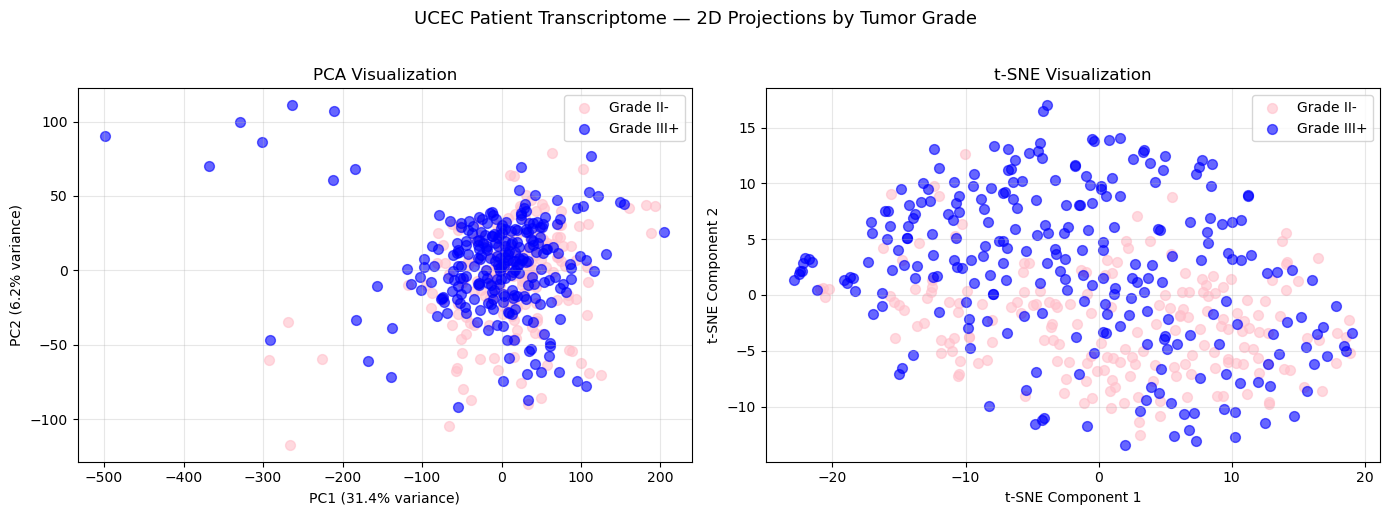

Total variance explained by PC1+PC2: 37.56%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

for label, color, name in [(0, 'pink', 'Grade II-'), (1, 'blue', 'Grade III+')]:
    mask = y_train == label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=name, alpha=0.6, s=50)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('PCA Visualization')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_train_scaled)

for label, color, name in [(0, 'pink', 'Grade II-'), (1, 'blue', 'Grade III+')]:
    mask = y_train == label
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=name, alpha=0.6, s=50)

axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].set_title('t-SNE Visualization')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('UCEC Patient Transcriptome — 2D Projections by Tumor Grade', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/patient_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Total variance explained by PC1+PC2: {sum(pca.explained_variance_ratio_)*100:.2f}%")

## 9. Final Model - Retrain on Full Training Set & Generate Predictions

The final model uses the full 444 sample training set (no held-out validation) to maximize the signal available before predicting on the 110 unseen test samples. The pipeline includes StandardScaler followed by Logistic Regression, consistent with the CV setup.

In [11]:
# Final pipeline
final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])
final_pipe.fit(X_train, y_train)

# Predict on held-out test set
test_predictions = final_pipe.predict(X_test)

submission = pd.DataFrame({
    'ID': test_ids,
    'xml_neoplasm_histologic_grade': test_predictions
})
submission.to_csv('../results/submission_final.csv', index=False)

print(f"Test predictions saved to ../results/submission_final.csv")
print(f"Total predictions:   {len(test_predictions)}")
print(f"Predicted Grade II-: {np.sum(test_predictions == 0)}")
print(f"Predicted Grade III+:{np.sum(test_predictions == 1)}")

print("\nPrediction distribution (%)")
print(f"  Grade II-  (0): {np.mean(test_predictions == 0)*100:.1f}%")
print(f"  Grade III+ (1): {np.mean(test_predictions == 1)*100:.1f}%")

PermissionError: [Errno 13] Permission denied: '../results/submission_final.csv'

## 10. Biological Interpretation of Top Genes

The table below summarizes the top 10 genes by |coefficient| and their known or putative relevance to UCEC (Uterine Corpus Endometrial Carcinoma):

| Ensembl ID | Gene Symbol | Direction | Biological Relevance to UCEC |
|---|---|---|---|
| ENSG00000071677 | PRLH | III+ | PRL/PRLR signaling promotes proliferation in endometrial cancer cells; elevated in uterine tumors |
| ENSG00000184502 | GRP/GAST family | II- | Bombesin/GRP receptors expressed in endometrial lines; VEGF coupling reported |
| ENSG00000091583 | APOL family | — | Lipid biology shifts in tumors; no robust direct UCEC signal found |
| ENSG00000168148 | H3-4 (histone) | — | H3K4me3 breadth altered in EC; ties to chromatin state, not a direct prognostic marker |
| ENSG00000204928 | Glutaredoxin family | — | Inner-ear/glutaredoxin; no strong EC association identified |
| ENSG00000133636 | NTS/NTSR1 | III+ | Neurotensin/NTSR1 axis implicated in hormone-sensitive cancers including endometrial |
| ENSG00000198812 | — | — | No clear UCEC link identified |
| ENSG00000064218 | Neuropeptide/GPCR | — | Pathway-level plausibility via GPCR/hormonal signaling in UCEC |
| ENSG00000177947 | — | — | No clear UCEC link identified |

**Takeaway:** Several top-ranked genes (PRLH, NTS/NTSR1, GRP signaling) align with known hormonal and proliferative axes in endometrial cancer, suggesting the logistic regression coefficients partially recapitulate real biology. However, genes with no identified UCEC association are also highly ranked — a reminder that in high-dimensional, small-n settings, coefficients reflect both real signal and statistical noise.